# Data Visualization with Matplotlib

## Introduction

In this notebook, we'll explore various visualizations using Python's **Matplotlib** library alongside **NumPy**, **Pandas**, and **yfinance** to analyze historical stock data. We'll work with three exchange-traded funds (ETFs) that represent different sectors:

- **SPY**: An ETF tracking the S&P 500 index (representing the overall U.S. stock market).
- **XLK**: A technology‐sector ETF.
- **XLV**: A healthcare‐sector ETF.


We'll create the following plots:
- **Line Plot:** To show trends in stock closing prices over time.
- **Scatter Plot:** To explore the relationship between daily returns.
- **Bar Plot:** To compare trading volumes.
- **Histogram:** To examine the distribution of daily returns.
- **Subplots:** To combine multiple visualizations in one figure.
- **Candlestick:** To represent open, high, low, and close prices in a single view. 

## Table of Contents

1. [Line Plot](#1) <br>
2. [Scatter Plot](#2) <br>
3. [Bar Plot](#3) <br>
4. [Histogram](#4) <br>
5. [Subplots](#5) <br>
6. [Candlestick](#6) <br>

---

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Rectangle

# Ensure plots are rendered inline (for Jupyter Notebook)
%matplotlib inline


## Load Stock Data

I'll define a function `fetch_stock_data` that downloads historical data from Yahoo Finance using the `yfinance` package. This function returns NumPy arrays for dates, open, high, low, close, and volume.


In [2]:
def fetch_stock_data(ticker, period='1y'):
    """
    Fetch stock data for the given ticker using yfinance.
    
    Parameters:
      - ticker: Stock symbol as a string (e.g., 'SPY')
      - period: Time period to fetch (default '1y')
      
    Returns:
      Tuple of NumPy arrays: (dates, open, high, low, close, volume)
    """
    data = yf.download(ticker, period=period)
    # The DataFrame's index contains dates
    dates = data.index.to_numpy(dtype='datetime64[D]')
    open_prices = data['Open'].to_numpy()
    high = data['High'].to_numpy()
    low = data['Low'].to_numpy()
    close = data['Close'].to_numpy()
    volume = data['Volume'].to_numpy()
    return dates, open_prices, high, low, close, volume

# Fetch data for each stock
dates_spy, open_spy, high_spy, low_spy, close_spy, volume_spy = fetch_stock_data('SPY')
dates_xlk, open_xlk, high_xlk, low_xlk, close_xlk, volume_xlk = fetch_stock_data('XLK')
dates_xlv, open_xlv, high_xlv, low_xlv, close_xlv, volume_xlv = fetch_stock_data('XLV')



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## 1. Line Plot <a id="1"></a>

A line plot is ideal for showing trends over time. Here, we plot the closing prices of SPY, XLK, and XLV.

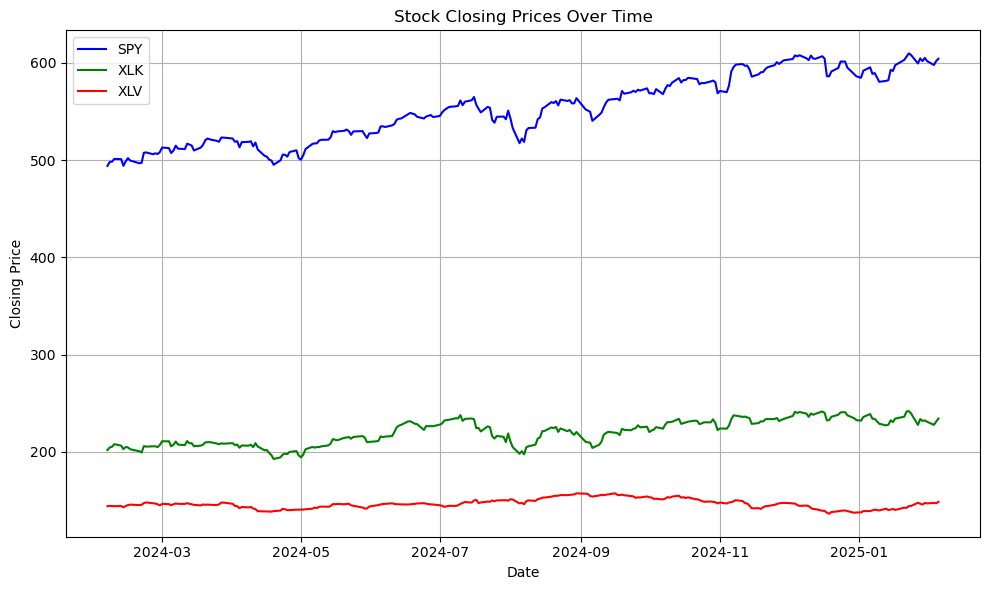

In [3]:
plt.figure(figsize=(10, 6))
plt.plot(dates_spy, close_spy, label='SPY', color='blue')
plt.plot(dates_xlk, close_xlk, label='XLK', color='green')
plt.plot(dates_xlv, close_xlv, label='XLV', color='red')
plt.title('Stock Closing Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 2. Scatter Plot <a id="2"></a>

Scatter plots help visualize the relationship between two variables. We'll compute the daily returns for SPY and XLK and then create a scatter plot.


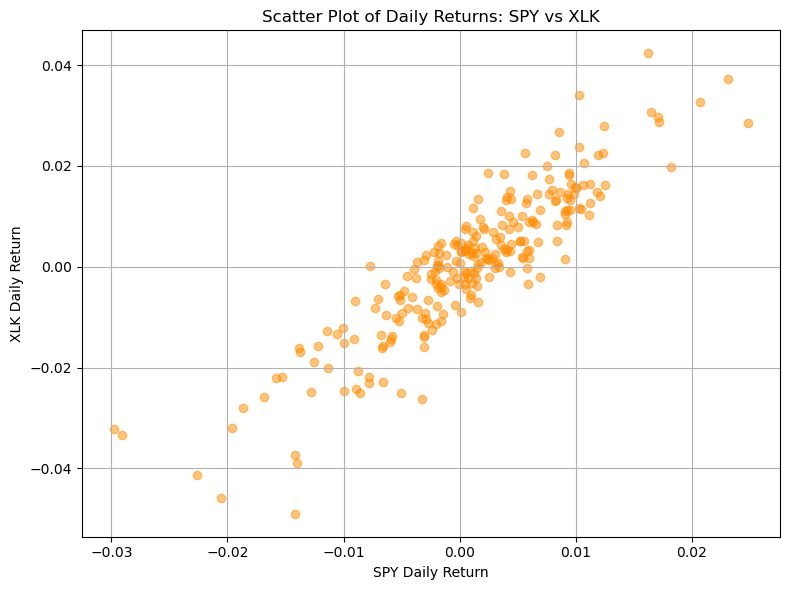

In [4]:
# Compute daily returns (simple returns) for SPY and XLK
returns_spy = close_spy[1:] / close_spy[:-1] - 1
returns_xlk = close_xlk[1:] / close_xlk[:-1] - 1

plt.figure(figsize=(8, 6))
plt.scatter(returns_spy, returns_xlk, alpha=0.5, color='darkorange')
plt.title('Scatter Plot of Daily Returns: SPY vs XLK')
plt.xlabel('SPY Daily Return')
plt.ylabel('XLK Daily Return')
plt.grid(True)
plt.tight_layout()
plt.show()


## 3. Bar Plot <a id="3"></a>

Bar plots are useful for comparing discrete values. Here, we plot the trading volume for the first 20 days of SPY.


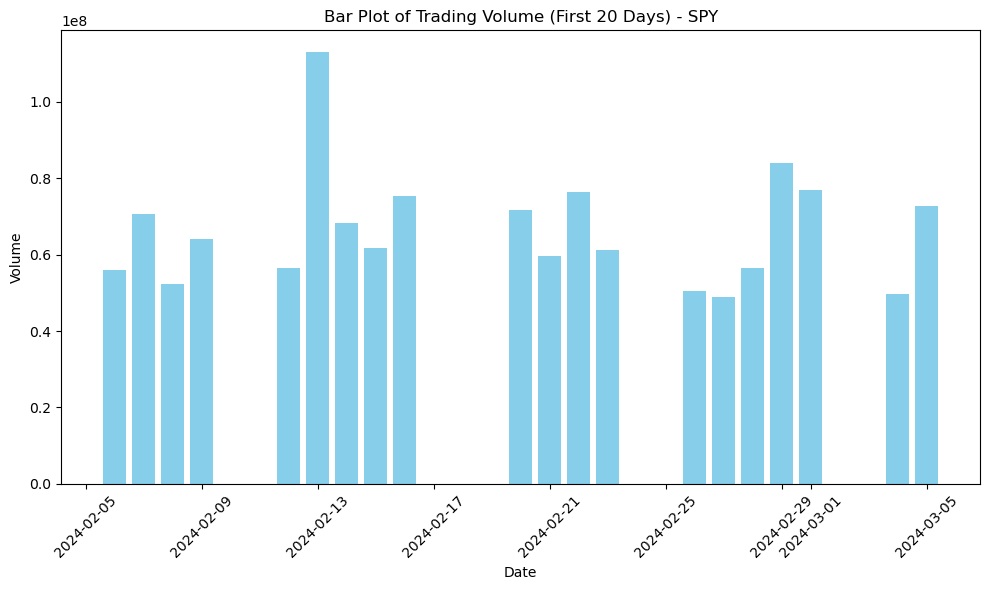

In [5]:
plt.figure(figsize=(10, 6))
plt.bar(dates_spy[:20], volume_spy[:20], color='skyblue')
plt.title('Bar Plot of Trading Volume (First 20 Days) - SPY')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 4. Histogram <a id="4"></a>

Histograms show the distribution of a variable. We will plot the histogram of SPY's daily returns, and then overlay SPY and XLK returns on one histogram.


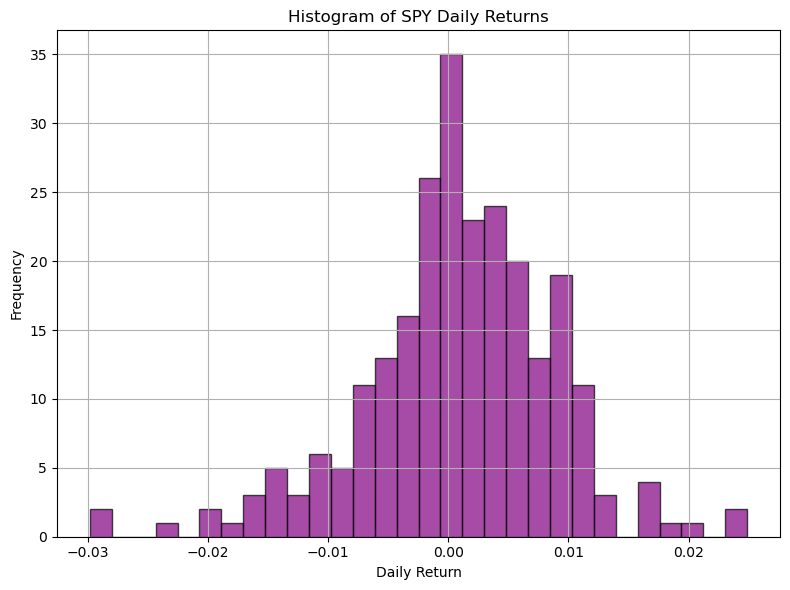

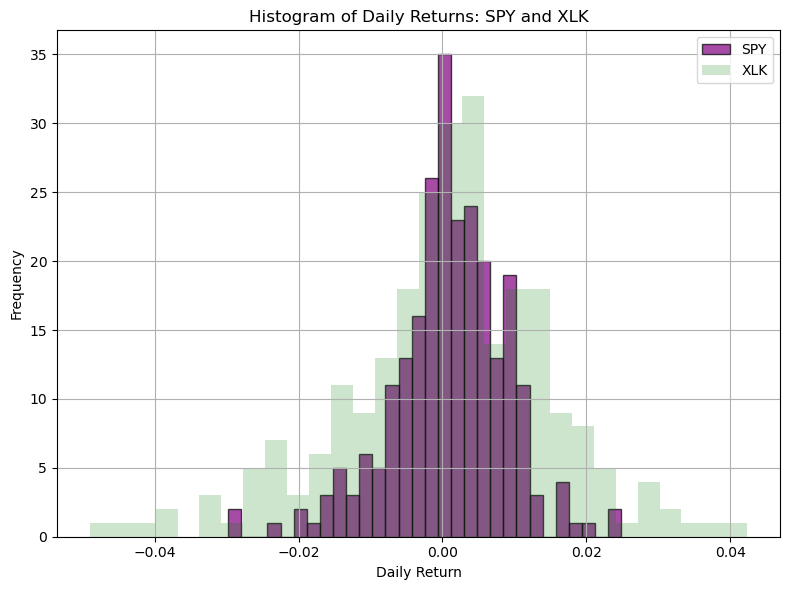

In [6]:
# Histogram for SPY daily returns
plt.figure(figsize=(8, 6))
plt.hist(returns_spy, bins=30, color='purple', edgecolor='black', alpha=0.7)
plt.title('Histogram of SPY Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# Overlaying histograms for SPY and XLK daily returns
plt.figure(figsize=(8, 6))
plt.hist(returns_spy, bins=30, color='purple', edgecolor='black', alpha=0.7, label='SPY')
plt.hist(returns_xlk, bins=30, color='green', alpha=0.2, label='XLK')
plt.title('Histogram of Daily Returns: SPY and XLK')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



## 5. Subplots <a id="5"></a>

Subplots allow you to display multiple related visualizations in one figure for easy comparison. In this section, we'll create a 2x2 grid of plots.


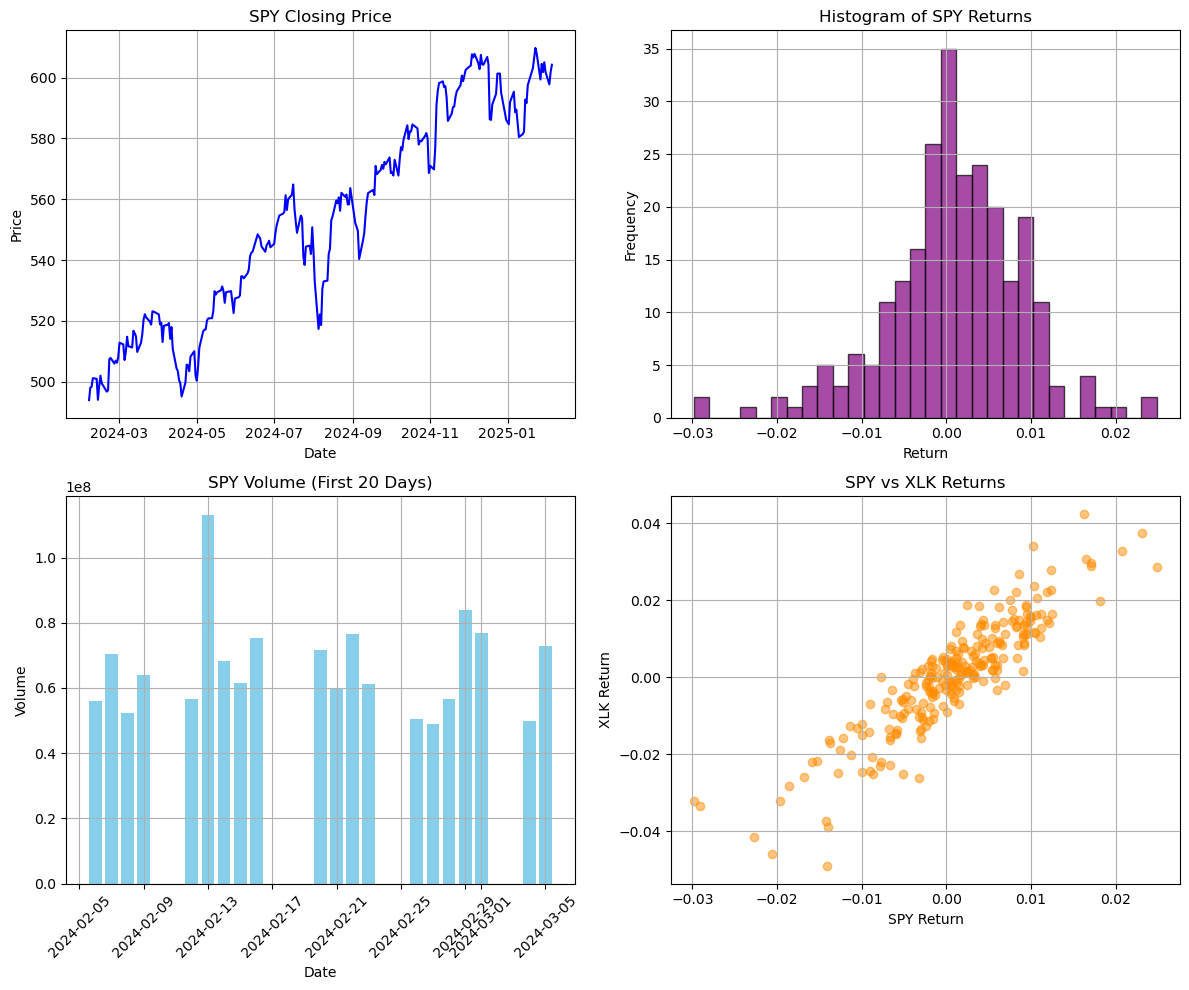

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Subplot 1: Line Plot of SPY Closing Price
axs[0, 0].plot(dates_spy, close_spy, color='blue')
axs[0, 0].set_title('SPY Closing Price')
axs[0, 0].set_xlabel('Date')
axs[0, 0].set_ylabel('Price')
axs[0, 0].grid(True)

# Subplot 2: Histogram of SPY Daily Returns
axs[0, 1].hist(returns_spy, bins=30, color='purple', edgecolor='black', alpha=0.7)
axs[0, 1].set_title('Histogram of SPY Returns')
axs[0, 1].set_xlabel('Return')
axs[0, 1].set_ylabel('Frequency')
axs[0, 1].grid(True)

# Subplot 3: Bar Plot of SPY Volume (first 20 days)
axs[1, 0].bar(dates_spy[:20], volume_spy[:20], color='skyblue')
axs[1, 0].set_title('SPY Volume (First 20 Days)')
axs[1, 0].set_xlabel('Date')
axs[1, 0].set_ylabel('Volume')
for label in axs[1, 0].get_xticklabels():
    label.set_rotation(45)
axs[1, 0].grid(True)

# Subplot 4: Scatter Plot of SPY vs XLK Daily Returns
axs[1, 1].scatter(returns_spy, returns_xlk, alpha=0.5, color='darkorange')
axs[1, 1].set_title('SPY vs XLK Returns')
axs[1, 1].set_xlabel('SPY Return')
axs[1, 1].set_ylabel('XLK Return')
axs[1, 1].grid(True)

plt.tight_layout()
plt.show()


## 6 Candlestick Chart <a id="6"></a>
Candlestick charts are standard in financial visualization to represent open, high, low, and close prices in a single view. 

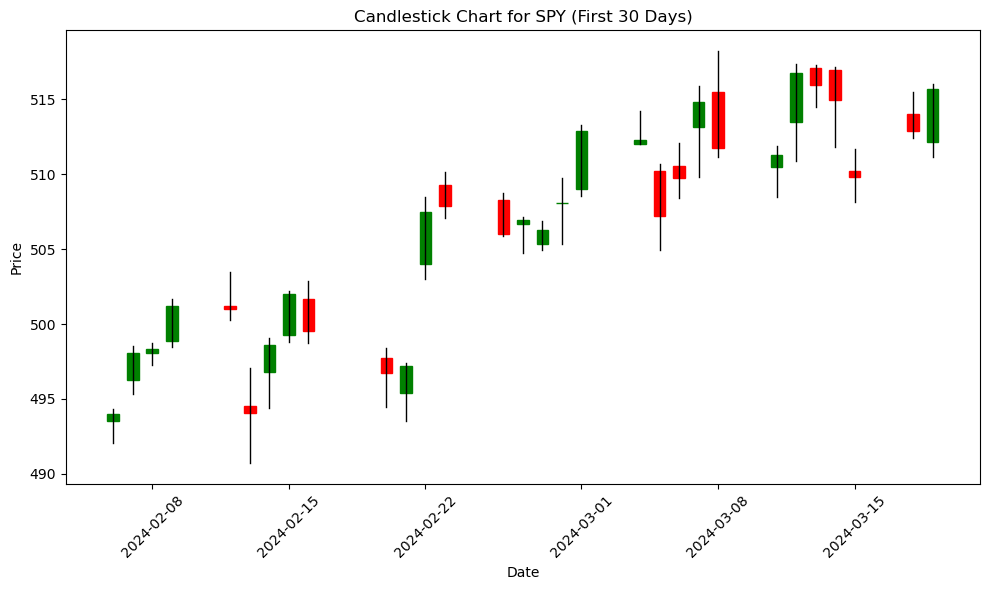

In [8]:
def plot_candlestick(ax, dates, opens, highs, lows, closes, width=0.6):
    """
    Plot a simple candlestick chart on the provided Axes.
    
    Parameters:
      - dates: Numeric dates (Matplotlib format)
      - opens, highs, lows, closes: Price arrays
      - width: Width of each candlestick body
    """
    for d, o, h, l, c in zip(dates, opens, highs, lows, closes):
        color = 'green' if c >= o else 'red'
        # Draw the high-low line
        ax.plot([d, d], [l, h], color='black', linewidth=1)
        # Determine the bottom and height of the rectangle (body)
        rect_bottom = o if c >= o else c
        rect_height = abs(c - o)
        # Draw the rectangle (body)
        rect = Rectangle((d - width/2, rect_bottom), width, rect_height, color=color)
        ax.add_patch(rect)

# Plotting a candlestick chart for the first 30 days of SPY data
num_days = 30
# Convert the first 30 dates to strings and then to Matplotlib date numbers
dates_spy_str = dates_spy[:num_days].astype(str)
dates_spy_num = mdates.datestr2num(dates_spy_str)

fig, ax = plt.subplots(figsize=(10, 6))
plot_candlestick(ax, dates_spy_num, open_spy[:num_days], high_spy[:num_days],
                 low_spy[:num_days], close_spy[:num_days], width=0.6)
ax.xaxis_date()  # Inform Matplotlib that the x-axis contains dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.title('Candlestick Chart for SPY (First 30 Days)')
plt.xlabel('Date')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Conclusion

In this notebook, we:
- Loaded historical stock data using **yfinance**.
- Created several types of plots using **Matplotlib**:
  - A **Line Plot** to show trends in closing prices.
  - A **Scatter Plot** to analyze the relationship between daily returns.
  - A **Bar Plot** to compare trading volume.
  - A **Histogram** to examine the distribution of daily returns.
  - **Subplots** to combine multiple visualizations for comparison.

These visualizations are powerful tools for exploratory data analysis, allowing you to gain insights from historical data quickly. 

**Plots**:

![Plot Types](../images/plot_types.png)
*Source*: DataCamp